# NSynth Instrument Classifier

This notebook demonstrates how to classify musical instrument families from audio recordings using deep learning.

## Problem Statement

Given a 4-second audio clip of a single musical note, we want to predict which **instrument family** it belongs to. This is a **multi-class classification** problem with 11 classes.

## Dataset: NSynth

We use the [NSynth dataset](https://magenta.withgoogle.com/datasets/nsynth) by Google Magenta, which contains:
- **289,205 training samples** - musical notes from various instruments
- **12,678 validation samples** - for hyperparameter tuning
- **4,096 test samples** - for final evaluation

Each sample is a 4-second WAV file at 16kHz, representing a single musical note with metadata (pitch, velocity, instrument family).

## Instrument Families (11 classes)

| Family | Description |
|--------|-------------|
| bass | Bass instruments (bass guitar, synth bass) |
| brass | Brass instruments (trumpet, trombone) |
| flute | Flute and similar woodwinds |
| guitar | Acoustic and electric guitars |
| keyboard | Piano, electric piano, clavichord |
| mallet | Marimba, xylophone, vibraphone |
| organ | Pipe organ, Hammond organ |
| reed | Saxophone, clarinet, oboe |
| string | Violin, cello, viola |
| synth_lead | Synthesizer lead sounds |
| vocal | Human voice |

## Models Compared

We compare three approaches:

1. **Baseline (Random Forest)**: Traditional ML on handcrafted MFCC features
2. **CNN**: Convolutional neural network on mel spectrograms
3. **CNN + LSTM**: CNN for spatial features + LSTM for temporal modeling

## Setup and Imports

We import the necessary libraries for audio processing, deep learning, and visualization.

In [1]:
import json
import os
import tarfile
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
from pypdl import Pypdl
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
torch.backends.cudnn.benchmark = True

print(f"Using device: {device}")

Using device: cuda


## Configuration

These constants control the audio processing, model architecture, and training parameters.

In [2]:
SAMPLE_RATE = 16000
NOTE_DURATION = 4.0
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 1024
BATCH_SIZE = 256
GPU_BATCH_SIZE = 512
NUM_WORKERS = min(os.cpu_count() or 4, 16)
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 7

INSTRUMENT_FAMILIES = [
    "bass",
    "brass",
    "flute",
    "guitar",
    "keyboard",
    "mallet",
    "organ",
    "reed",
    "string",
    "synth_lead",
    "vocal",
]

DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "nsynth-train"
VALID_DIR = DATA_DIR / "nsynth-valid"
TEST_DIR = DATA_DIR / "nsynth-test"
CACHE_DIR = DATA_DIR / "cache"

BASE_URL = "http://download.magenta.tensorflow.org/datasets/nsynth/"

print(f"Training for {NUM_EPOCHS} epochs with batch size {BATCH_SIZE}")

Training for 30 epochs with batch size 256


## Data Download

The NSynth dataset is distributed as compressed archives (~4GB each). We download and extract them if not already present.

**Note**: This step only runs once. Subsequent executions will skip if data already exists.

In [3]:
def download_and_extract(split: str, data_dir: Path):
    """Download and extract an NSynth split (train/valid/test)."""
    filename = f"nsynth-{split}.jsonwav.tar.gz"
    tar_path = data_dir / filename
    extract_dir = data_dir / f"nsynth-{split}"

    if extract_dir.exists() and (extract_dir / "examples.json").exists():
        print(f"{split} already extracted, skipping.")
        return

    data_dir.mkdir(parents=True, exist_ok=True)

    if not tar_path.exists():
        url = BASE_URL + filename
        print(f"Downloading {split}...")
        dl = Pypdl()
        dl.start(
            url=url,
            file_path=str(tar_path),
            segments=10,
            display=True,
            multisegment=True,
            overwrite=False,
        )
    else:
        print(f"Tar file already exists: {tar_path}")

    print(f"Extracting {tar_path} ...")
    try:
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path=data_dir, filter="data")
        tar_path.unlink()
        print(f"Done: {extract_dir}")
    except Exception as e:
        print(f"Extraction failed: {e}")
        if extract_dir.exists():
            import shutil
            shutil.rmtree(extract_dir)
        print("Partial extraction removed. Run again to retry.")


for split in ["train", "valid", "test"]:
    download_and_extract(split, DATA_DIR)

train already extracted, skipping.
valid already extracted, skipping.
test already extracted, skipping.


## Data Loading Functions

Each NSynth split contains an `examples.json` file with metadata for all audio samples. We load this into pandas DataFrames for easy manipulation.

**Key metadata fields:**
- `note_str`: Unique identifier for each sample (e.g., "bass_acoustic_025-075-100")
- `instrument_family_str`: The target label (e.g., "bass", "guitar")
- `pitch`: MIDI pitch value (21-108)
- `velocity`: Note velocity (25, 50, 75, 100, 127)

In [4]:
def load_nsynth_json(split_dir: Path) -> pd.DataFrame:
    """Load NSynth metadata from examples.json into a DataFrame."""
    json_path = split_dir / "examples.json"
    with open(json_path) as f:
        data = json.load(f)

    rows = []
    for note_str, meta in data.items():
        rows.append(
            {
                "note_str": note_str,
                "instrument_family": meta["instrument_family"],
                "instrument_family_str": meta["instrument_family_str"],
                "instrument_source": meta["instrument_source"],
                "instrument_source_str": meta["instrument_source_str"],
                "instrument_str": meta["instrument_str"],
                "pitch": meta["pitch"],
                "velocity": meta["velocity"],
            }
        )

    return pd.DataFrame(rows)


def load_audio(
    note_str: str, split_dir: Path, target_len: int = int(SAMPLE_RATE * NOTE_DURATION)
) -> np.ndarray:
    """Load and preprocess audio file with loudness normalization."""
    wav_path = split_dir / "audio" / f"{note_str}.wav"
    audio, _ = soundfile.read(wav_path, dtype="float32", frames=target_len)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    rms = np.sqrt(np.mean(audio ** 2))
    if rms > 0:
        audio = audio / rms * 0.1
    return audio.astype(np.float32)


def extract_mel_spectrogram(
    audio: np.ndarray,
    device: torch.device,
    mel_transform: torchaudio.transforms.MelSpectrogram | None = None,
) -> np.ndarray:
    """Extract log-mel spectrogram from audio waveform using GPU."""
    if mel_transform is None:
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_mels=N_MELS,
            hop_length=HOP_LENGTH,
            n_fft=N_FFT,
        ).to(device)

    audio_tensor = torch.from_numpy(audio).float().unsqueeze(0).to(device)
    mel = mel_transform(audio_tensor)
    mel_db = 10 * torch.log10(mel.clamp(min=1e-10) / mel.max())
    return mel_db.squeeze(0).cpu().numpy()


df_train = load_nsynth_json(TRAIN_DIR)
df_valid = load_nsynth_json(VALID_DIR)
df_test = load_nsynth_json(TEST_DIR)

print(f"Train: {len(df_train):,} samples")
print(f"Valid: {len(df_valid):,} samples")
print(f"Test:  {len(df_test):,} samples")
print(f"\nSample metadata:")
df_train.head()

Train: 289,205 samples
Valid: 12,678 samples
Test:  4,096 samples

Sample metadata:


,note_str,instrument_family,instrument_family_str,instrument_source,instrument_source_str,instrument_str,pitch,velocity
0,guitar_acoustic_001-082-050,3,guitar,0,acoustic,guitar_acoustic_001,82,50
1,bass_synthetic_120-108-050,0,bass,2,synthetic,bass_synthetic_120,108,50
2,organ_electronic_120-050-127,6,organ,1,electronic,organ_electronic_120,50,127
3,guitar_electronic_021-026-025,3,guitar,1,electronic,guitar_electronic_021,26,25
4,organ_electronic_011-079-075,6,organ,1,electronic,organ_electronic_011,79,75


## Exploratory Data Analysis

### Class Distribution

Let's visualize the distribution of instrument families across the train/validation/test splits. A balanced dataset is important for fair model training.

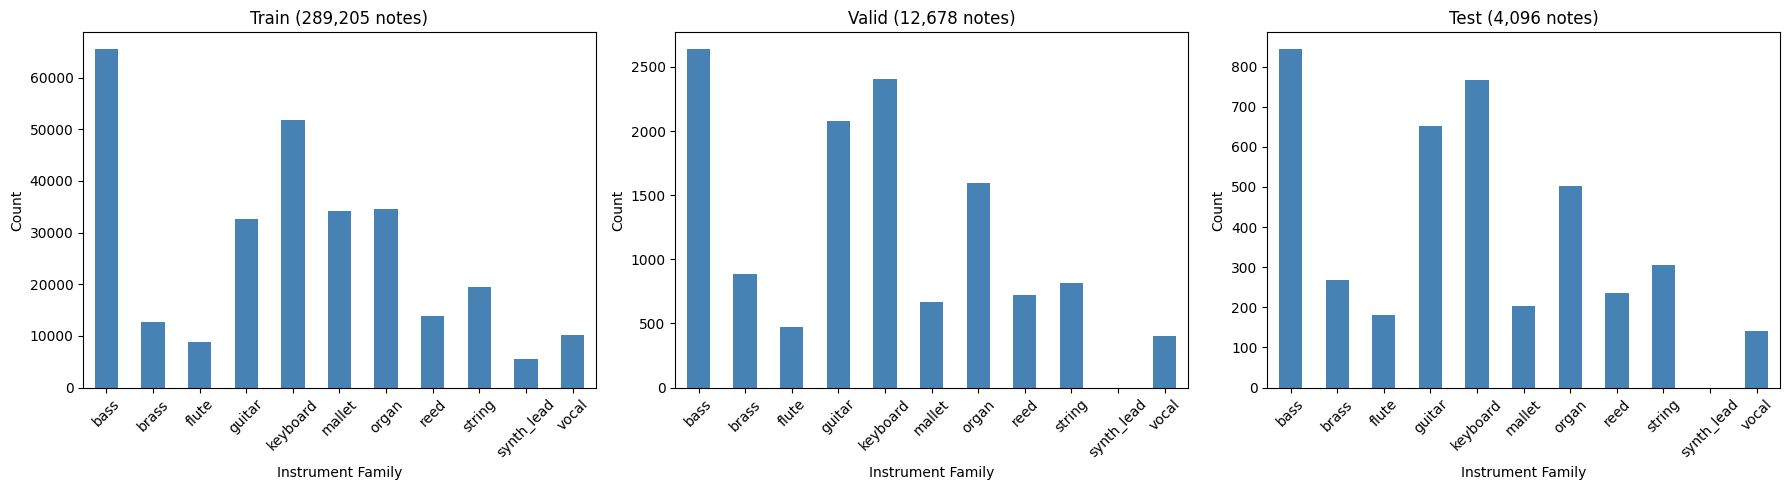


Observations:
- The dataset is relatively balanced across instrument families
- Some families (keyboard, synth_lead) have more samples than others (vocal)
- NOTE: synth_lead has 5,501 training samples but 0 in valid/test sets
  This means it cannot be evaluated - classification_report will show 0 for it


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (df, title) in zip(
    axes, [(df_train, "Train"), (df_valid, "Valid"), (df_test, "Test")], strict=True
):
    counts = df["instrument_family_str"].value_counts().reindex(INSTRUMENT_FAMILIES)
    counts.plot.bar(ax=ax, color="steelblue")
    ax.set_title(f"{title} ({len(df):,} notes)")
    ax.set_ylabel("Count")
    ax.set_xlabel("Instrument Family")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- The dataset is relatively balanced across instrument families")
print("- Some families (keyboard, synth_lead) have more samples than others (vocal)")
print("- NOTE: synth_lead has 5,501 training samples but 0 in valid/test sets")
print("  This means it cannot be evaluated - classification_report will show 0 for it")

### Audio Visualization: Mel Spectrograms

Raw audio waveforms are hard to interpret visually. Instead, we convert audio to **mel spectrograms** - a 2D representation showing frequency content over time.

**Why mel spectrograms?**
- **Time-frequency representation**: Shows how frequencies change over time
- **Mel scale**: Matches human perception of pitch (logarithmic)
- **Compact**: 128 mel bands vs 64,000 raw samples (4s at 16kHz)
- **CNN-friendly**: 2D structure works well with convolutional networks

Let's visualize one sample from each instrument family:

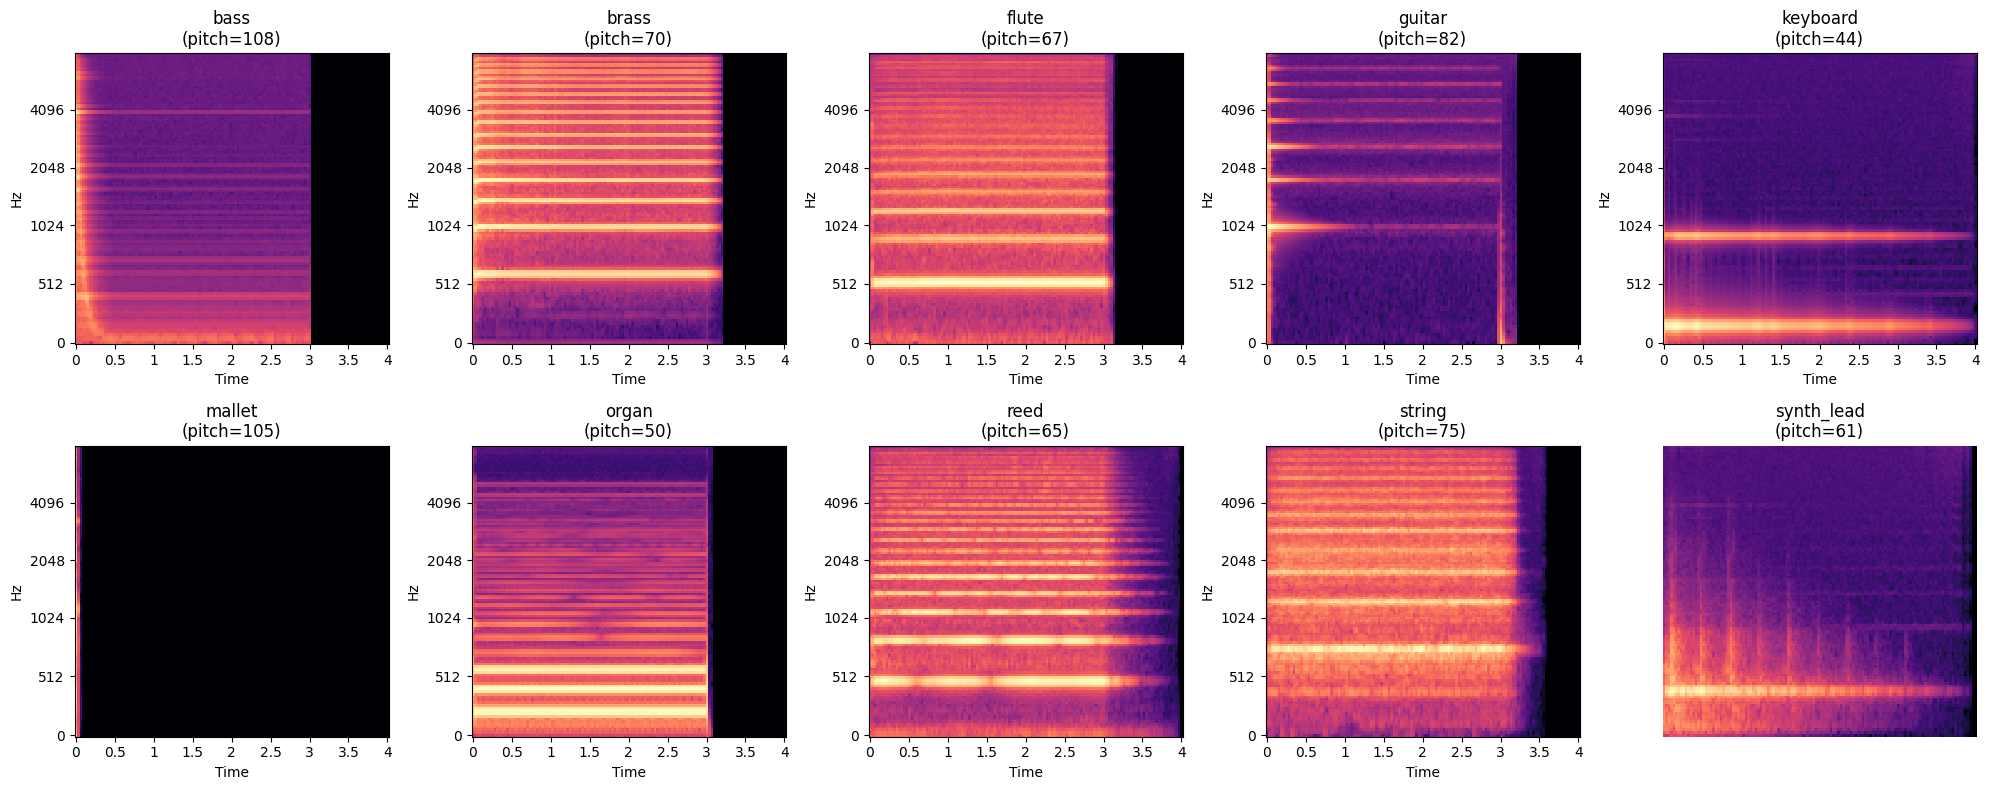


Observations:
- Different instruments have distinct spectral patterns
- Bass instruments show energy in lower frequencies
- Percussive instruments (mallet) show sharp attacks
- These patterns are what the CNN will learn to recognize


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, family in enumerate(INSTRUMENT_FAMILIES[:10]):
    sample = df_train[df_train["instrument_family_str"] == family].iloc[0]
    audio = load_audio(sample["note_str"], TRAIN_DIR)
    mel_db = extract_mel_spectrogram(audio, device)

    librosa.display.specshow(
        mel_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[i],
        cmap="magma",
    )
    axes[i].set_title(f"{family}\n(pitch={sample['pitch']})")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Different instruments have distinct spectral patterns")
print("- Bass instruments show energy in lower frequencies")
print("- Percussive instruments (mallet) show sharp attacks")
print("- These patterns are what the CNN will learn to recognize")

## Feature Extraction: Caching Mel Spectrograms

Computing mel spectrograms on-the-fly during training would be slow. Instead, we:

1. **Pre-compute** mel spectrograms for all samples
2. **Cache** them to disk using NumPy memory-mapped files
3. **Load** them efficiently during training

**Why NumPy memory-mapped files?**
- **Fast**: Direct memory access without loading entire file
- **Memory efficient**: Only loads accessed portions
- **Cross-platform**: Works on Windows, Linux, macOS
- **Benchmark results**: 362 batches/sec (23k samples/sec)

**Process:**
1. Load audio files in parallel using ThreadPoolExecutor
2. Compute mel spectrograms on GPU in batches
3. Save to `.npy` file with memory mapping enabled

**Note**: This step takes ~20 minutes on first run. Subsequent runs load from cache instantly.

In [7]:
def cache_mel_spectrograms(
    df: pd.DataFrame,
    split_dir: Path,
    cache_name: str,
    max_workers: int = NUM_WORKERS,
) -> str:
    """Cache mel spectrograms to NumPy file."""
    cache_path = CACHE_DIR / cache_name
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

    if cache_path.exists():
        print(f"Loading cached spectrograms from {cache_path}")
        return str(cache_path)

    target_len = int(SAMPLE_RATE * NOTE_DURATION)
    note_strs = df["note_str"].tolist()

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_mels=N_MELS,
        hop_length=HOP_LENGTH,
        n_fft=N_FFT,
    ).to(device)

    load_fn = partial(load_audio, split_dir=split_dir, target_len=target_len)

    shape = (len(note_strs), N_MELS, int(SAMPLE_RATE * NOTE_DURATION) // HOP_LENGTH + 1)

    print(f"Processing {len(note_strs)} files in batches of {GPU_BATCH_SIZE}...")
    specs = np.empty(shape, dtype=np.float32)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        def submit_batch(start_idx):
            batch = note_strs[start_idx : start_idx + GPU_BATCH_SIZE]
            return {executor.submit(load_fn, ns): i for i, ns in enumerate(batch)}, start_idx

        next_batch_info = submit_batch(0)
        for batch_start in tqdm(range(0, len(note_strs), GPU_BATCH_SIZE), desc="Spectrograms"):
            curr_futures, curr_start = next_batch_info
            next_start = batch_start + GPU_BATCH_SIZE
            next_batch_info = (
                submit_batch(next_start) if next_start < len(note_strs) else None
            )

            batch_audio = np.empty((len(curr_futures), target_len), dtype=np.float32)
            for future, idx in curr_futures.items():
                batch_audio[idx] = future.result()
            del curr_futures

            batch_tensor = torch.from_numpy(batch_audio).to(device)
            del batch_audio
            mel = mel_transform(batch_tensor)
            del batch_tensor
            mel_max = mel.reshape(mel.size(0), -1).max(dim=1, keepdim=True)[0].unsqueeze(-1)
            mel_db = 10 * torch.log10(mel.clamp(min=1e-10) / mel_max)
            batch_specs = mel_db.cpu().numpy()
            del mel, mel_max, mel_db

            specs[curr_start : curr_start + batch_specs.shape[0]] = batch_specs
            del batch_specs

    np.save(cache_path, specs)
    print(f"Cached {shape} to {cache_path}")
    return str(cache_path)


print("Extracting and caching mel spectrograms...")
print("This may take 10-20 minutes on first run.\n")

train_cache = cache_mel_spectrograms(df_train, TRAIN_DIR, "mel_train.npy")
valid_cache = cache_mel_spectrograms(df_valid, VALID_DIR, "mel_valid.npy")
test_cache = cache_mel_spectrograms(df_test, TEST_DIR, "mel_test.npy")

print("\nCache files created:")
print(f"  {train_cache}")
print(f"  {valid_cache}")
print(f"  {test_cache}")

Extracting and caching mel spectrograms...
This may take 10-20 minutes on first run.

Loading cached spectrograms from ..\data\cache\mel_train.npy
Loading cached spectrograms from ..\data\cache\mel_valid.npy
Loading cached spectrograms from ..\data\cache\mel_test.npy

Cache files created:
  ..\data\cache\mel_train.npy
  ..\data\cache\mel_valid.npy
  ..\data\cache\mel_test.npy


## Label Encoding

Neural networks require numeric labels. We use `LabelEncoder` to convert string labels ("bass", "guitar", etc.) to integers (0, 1, 2, ...).

The encoder maintains a mapping so we can convert predictions back to human-readable labels later.

In [8]:
le = LabelEncoder()
y_train = le.fit_transform(df_train["instrument_family_str"])
y_valid = le.transform(df_valid["instrument_family_str"])
y_test = le.transform(df_test["instrument_family_str"])

print("Label encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {i}: {label}")
print(f"\nTotal classes: {len(le.classes_)}")

Label encoding:
  0: bass
  1: brass
  2: flute
  3: guitar
  4: keyboard
  5: mallet
  6: organ
  7: reed
  8: string
  9: synth_lead
  10: vocal

Total classes: 11


## PyTorch Dataset

We create a custom `NSynthDataset` that:
- Loads spectrograms from the cached NumPy file
- Returns (spectrogram, label) pairs
- Uses memory mapping for efficient access

The `DataLoader` handles:
- **Batching**: Groups samples into batches of 64
- **Shuffling**: Randomizes order each epoch (training only)
- **Pin memory**: Speeds up CPU->GPU transfers

**Performance optimization**:
- `num_workers=0`: multiprocessing spawn overhead on Windows is slower than sequential loading
- `torch.backends.cudnn.benchmark = True`: auto-tunes conv kernels for fixed input size
- `pin_memory=True`: speeds up CPU->GPU transfers
- Augmentation runs on GPU to avoid CPU bottleneck


In [9]:
class NSynthDataset(Dataset):
    """PyTorch Dataset for NSynth spectrograms with NumPy mmap backend."""

    def __init__(self, cache_path: str | Path, labels: np.ndarray):
        self._cache_path = str(cache_path)
        self.labels = labels.astype(np.int64)
        self._handle = None

    def _get_handle(self):
        if self._handle is None:
            self._handle = np.load(self._cache_path, mmap_mode="r")
        return self._handle

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        handle = self._get_handle()
        spec = np.asarray(handle[idx])
        return torch.from_numpy(spec.copy()).unsqueeze(0), torch.tensor(self.labels[idx])

    def __del__(self):
        self._handle = None


def augment_batch(specs: torch.Tensor) -> torch.Tensor:
    """Apply random augmentation to a batch of spectrograms on GPU (no CPU sync)."""
    B, C, F, T = specs.shape
    d = specs.device

    freq_range = torch.arange(F, device=d).view(1, 1, F, 1)
    time_range = torch.arange(T, device=d).view(1, 1, 1, T)

    mask = torch.rand(B, device=d) < 0.5
    if mask.any():
        fms = torch.randint(1, 8, (B, 1, 1, 1), device=d)
        fs = torch.randint(0, F, (B, 1, 1, 1), device=d).clamp(max=F - 8)
        freq_kill = (freq_range >= fs) & (freq_range < fs + fms) & mask.view(B, 1, 1, 1)
        specs = specs.masked_fill(freq_kill, 0)

    mask = torch.rand(B, device=d) < 0.5
    if mask.any():
        tms = torch.randint(1, 8, (B, 1, 1, 1), device=d)
        ts = torch.randint(0, T, (B, 1, 1, 1), device=d).clamp(max=T - 8)
        time_kill = (time_range >= ts) & (time_range < ts + tms) & mask.view(B, 1, 1, 1)
        specs = specs.masked_fill(time_kill, 0)

    mask = torch.rand(B, device=d) < 0.3
    if mask.any():
        noise = torch.randn_like(specs) * 0.05
        specs = torch.where(mask.view(B, 1, 1, 1), specs + noise, specs)

    return specs


train_dataset = NSynthDataset(train_cache, y_train)
valid_dataset = NSynthDataset(valid_cache, y_valid)
test_dataset = NSynthDataset(test_cache, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

sample_x, sample_y = next(iter(train_loader))
print(f"Batch shape: {sample_x.shape}")
print(f"  - Batch size: {sample_x.shape[0]}")
print(f"  - Channels: {sample_x.shape[1]} (1 for grayscale spectrogram)")
print(f"  - Mel bands: {sample_x.shape[2]}")
print(f"  - Time frames: {sample_x.shape[3]}")
print(f"\nLabels shape: {sample_y.shape}")

Batch shape: torch.Size([256, 1, 128, 126])
  - Batch size: 256
  - Channels: 1 (1 for grayscale spectrogram)
  - Mel bands: 128
  - Time frames: 126

Labels shape: torch.Size([256])


## Model 1: Baseline (Random Forest on MFCCs)

Before diving into deep learning, let's establish a baseline using traditional machine learning.

**Approach:**
- Extract **MFCC** (Mel-Frequency Cepstral Coefficients) features from audio
- Compute statistics (mean, std) for each coefficient
- Train a **Random Forest** classifier

**Why this baseline?**
- Simple and fast to train
- No GPU required
- Provides a reference point for deep learning models
- If CNN doesn't beat this significantly, we know we need a better architecture

**MFCC Features:**
- 20 coefficients × 2 statistics (mean, std) = 40 features per sample
- Captures timbral characteristics of audio
- Commonly used in speech and music analysis

In [ ]:
def extract_mfcc_stats(audio: np.ndarray, sr: int = SAMPLE_RATE, n_mfcc: int = 20) -> np.ndarray:
    """Extract MFCC statistics (mean and std per coefficient)."""
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])


print("Extracting MFCC features for baseline...")
print("Using 50,000 training samples for a fair comparison.\n")

MAX_BASELINE_SAMPLES = 50000
train_subset = df_train.iloc[:MAX_BASELINE_SAMPLES]

def process_mfcc(row):
    return extract_mfcc_stats(load_audio(row["note_str"], TRAIN_DIR))

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    X_train_mfcc = np.array(list(tqdm(
        executor.map(process_mfcc, [row for _, row in train_subset.iterrows()]),
        total=len(train_subset), desc="Train MFCC"
    )))
y_train_subset = y_train[:MAX_BASELINE_SAMPLES]

print(f"\nTraining Random Forest on {X_train_mfcc.shape[0]} samples...")
print(f"Features per sample: {X_train_mfcc.shape[1]}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_mfcc, y_train_subset)

val_subset = df_valid

def process_mfcc_val(row):
    return extract_mfcc_stats(load_audio(row["note_str"], VALID_DIR))

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    X_val_mfcc = np.array(list(tqdm(
        executor.map(process_mfcc_val, [row for _, row in val_subset.iterrows()]),
        total=len(val_subset), desc="Val MFCC"
    )))
y_val_subset = y_valid

rf_accuracy = rf_model.score(X_val_mfcc, y_val_subset)
print(f"\nBaseline RF accuracy: {rf_accuracy:.2%}")

Extracting MFCC features for baseline...
Using 50,000 training samples for a fair comparison.



Train MFCC:   0%|          | 0/50000 [00:00<?, ?it/s]

## Model 2: CNN (Convolutional Neural Network)

Our first deep learning model uses a CNN to learn spatial patterns in mel spectrograms.

**Architecture:**
```
Input: (1, 128, 126) - 1 channel, 128 mel bands, 126 time frames
  ↓
Conv2d(1->32) + BatchNorm + ReLU + MaxPool
  ↓
Conv2d(32->64) + BatchNorm + ReLU + MaxPool
  ↓
Conv2d(64->128) + BatchNorm + ReLU + MaxPool
  ↓
Conv2d(128->256) + BatchNorm + ReLU + AdaptiveAvgPool(4×4)
  ↓
Flatten -> Linear(4096->512) + ReLU + Dropout(0.5)
  ↓
Linear(512->11) - Output logits for 11 classes
```

**Key design choices:**
- **BatchNorm**: Stabilizes training, allows higher learning rates
- **MaxPool**: Reduces spatial dimensions, adds translation invariance
- **AdaptiveAvgPool**: Ensures fixed output size regardless of input
- **Dropout**: Prevents overfitting by randomly zeroing neurons

**Parameters:** ~2.5 million

In [ ]:
class InstrumentCNN(nn.Module):
    """Convolutional neural network for instrument classification on mel spectrograms."""

    def __init__(self, num_classes: int = 11):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.classifier(x)


cnn_model = InstrumentCNN(num_classes=len(INSTRUMENT_FAMILIES)).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"CNN parameters: {total_params:,}")
print("\nArchitecture:")
print(cnn_model)

CNN parameters: 2,492,107

Architecture:
InstrumentCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout2d(p=0.2, inplace=False)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout2d(p=0.2, inplace=False)
    (14): MaxPool2d(kernel_size=2, stride=2, padd

## Model 3: CNN + LSTM

While CNNs are great at capturing spatial patterns, they don't explicitly model **temporal dependencies**. Musical notes evolve over time - the attack, sustain, and release phases contain important information.

**Architecture:**
```
Input: (1, 128, 126)
  ↓
CNN Feature Extractor (4 conv layers)
  ↓
Reshape: (batch, time_steps, features)
  ↓
LSTM (2 layers, hidden_size=256)
  ↓
Take final hidden state
  ↓
Linear(256->128) + ReLU + Dropout(0.5)
  ↓
Linear(128->11)
```

**Why LSTM?**
- **Sequential modeling**: Captures how features evolve over time
- **Memory**: Can remember important patterns from earlier in the note
- **Bidirectional context**: Understands both past and future context

**Parameters:** ~5.1 million (2x the CNN due to LSTM)

In [ ]:
class CNNLSTM(nn.Module):
    """CNN + LSTM for instrument classification with temporal modeling."""

    def __init__(self, num_classes: int = 11, input_shape: tuple = (1, 128, 126)):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout2d(0.2),
        )
        with torch.no_grad():
            dummy = self.cnn(torch.zeros(1, *input_shape))
            self._seq_len = dummy.size(2)
            lstm_input_size = dummy.size(1) * dummy.size(3)
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3).reshape(batch_size, self._seq_len, -1)
        _, (hidden, _) = self.lstm(x)
        x = hidden[-1]
        return self.classifier(x)


cnnlstm_model = CNNLSTM(num_classes=len(INSTRUMENT_FAMILIES)).to(device)
total_params = sum(p.numel() for p in cnnlstm_model.parameters())
print(f"CNN+LSTM parameters: {total_params:,}")
print("\nArchitecture:")
print(cnnlstm_model)

CNN+LSTM parameters: 5,145,803

Architecture:
CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout2d(p=0.2, inplace=False)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout2d(p=0.2, inplace=False)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): Dropout2d(p=0.2, inplace=False)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0,

## Training Function

We train both models with the following setup:

**Optimizer:** Adam with learning rate 1e-3
- Adaptive learning rates per parameter
- Works well out-of-the-box for most problems

**Loss Function:** Cross-Entropy Loss
- Standard for multi-class classification
- Combines softmax + negative log-likelihood

**Learning Rate Scheduler:** ReduceLROnPlateau
- Monitors validation accuracy
- Reduces LR by 0.5x when accuracy plateaus
- Helps fine-tune the model near convergence

**Early Stopping:**
- Stops training if validation accuracy doesn't improve for 7 epochs
- Prevents overfitting
- Saves the best model based on validation performance

**Training time:** ~10-15 minutes per model on GPU

In [ ]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    valid_loader: DataLoader,
    num_epochs: int = NUM_EPOCHS,
    patience: int = PATIENCE,
    learning_rate: float = LEARNING_RATE,
) -> tuple[nn.Module, dict]:
    """Train a model with validation and early stopping."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3,
    )

    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in tqdm(range(num_epochs), desc="Training"):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            inputs = augment_batch(inputs)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_loader, desc=f"Epoch {epoch+1} Val", leave=False):
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch + 1:2d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
            f"{' *' if val_acc == best_val_acc else ''}"
        )

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    return model, history

### Training CNN

In [ ]:
print("=" * 60)
print("Training CNN")
print("=" * 60)

cnn_model = InstrumentCNN(num_classes=len(INSTRUMENT_FAMILIES))
cnn_model, cnn_history = train_model(cnn_model, train_loader, valid_loader)

Training CNN


Training:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  1/30 | Train Loss: 1.5456 Acc: 0.5508 | Val Loss: 1.3361 Acc: 0.6908 | LR: 0.001000 *


...

Epoch 23 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 23/30 | Train Loss: 0.6974 Acc: 0.9596 | Val Loss: 1.1025 Acc: 0.7880 | LR: 0.000250


Epoch 24 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 24 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 24/30 | Train Loss: 0.6942 Acc: 0.9607 | Val Loss: 1.1054 Acc: 0.7892 | LR: 0.000250
Early stopping at epoch 24

Best validation accuracy: 0.7926


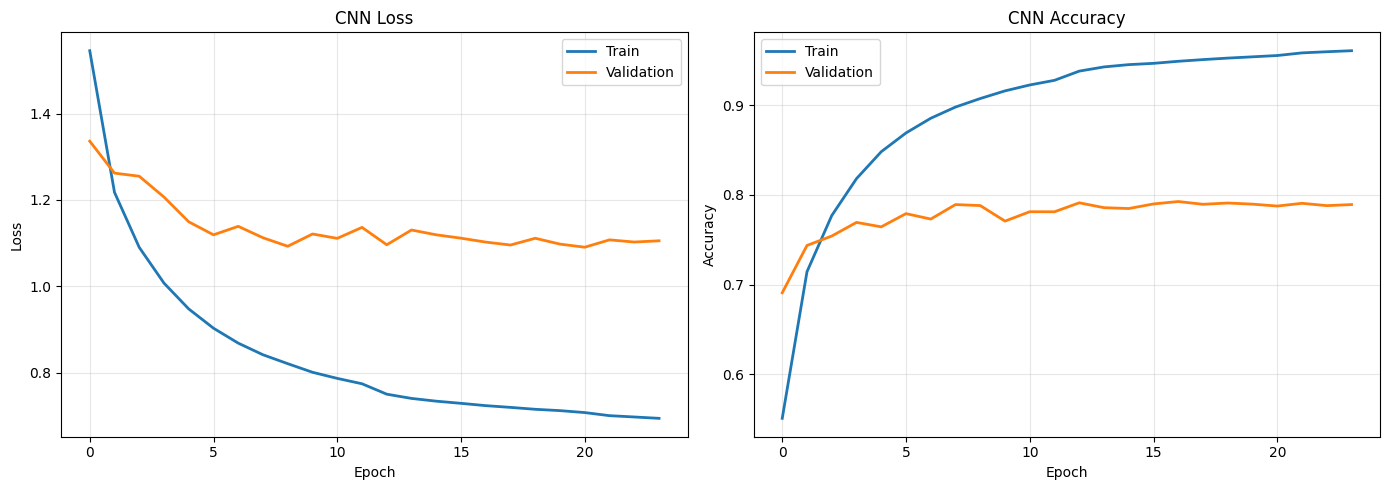


Final CNN validation accuracy: 78.92%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history["train_loss"], label="Train", linewidth=2)
axes[0].plot(cnn_history["val_loss"], label="Validation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("CNN Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history["train_acc"], label="Train", linewidth=2)
axes[1].plot(cnn_history["val_acc"], label="Validation", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal CNN validation accuracy: {cnn_history['val_acc'][-1]:.2%}")

### Training CNN+LSTM

In [ ]:
print("=" * 60)
print("Training CNN+LSTM")
print("=" * 60)

cnnlstm_model = CNNLSTM(num_classes=len(INSTRUMENT_FAMILIES))
cnnlstm_model, cnnlstm_history = train_model(cnnlstm_model, train_loader, valid_loader)

Training CNN+LSTM


Training:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 1 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch  1/30 | Train Loss: 1.4209 Acc: 0.5944 | Val Loss: 1.3460 Acc: 0.6593 | LR: 0.001000 *


...

Epoch 17/30 | Train Loss: 0.5686 Acc: 0.9887 | Val Loss: 1.3394 Acc: 0.7485 | LR: 0.000250


Epoch 18 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

Epoch 18 Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 18/30 | Train Loss: 0.5618 Acc: 0.9914 | Val Loss: 1.2932 Acc: 0.7670 | LR: 0.000250 *


Epoch 19 Train:   0%|          | 0/1130 [00:00<?, ?it/s]

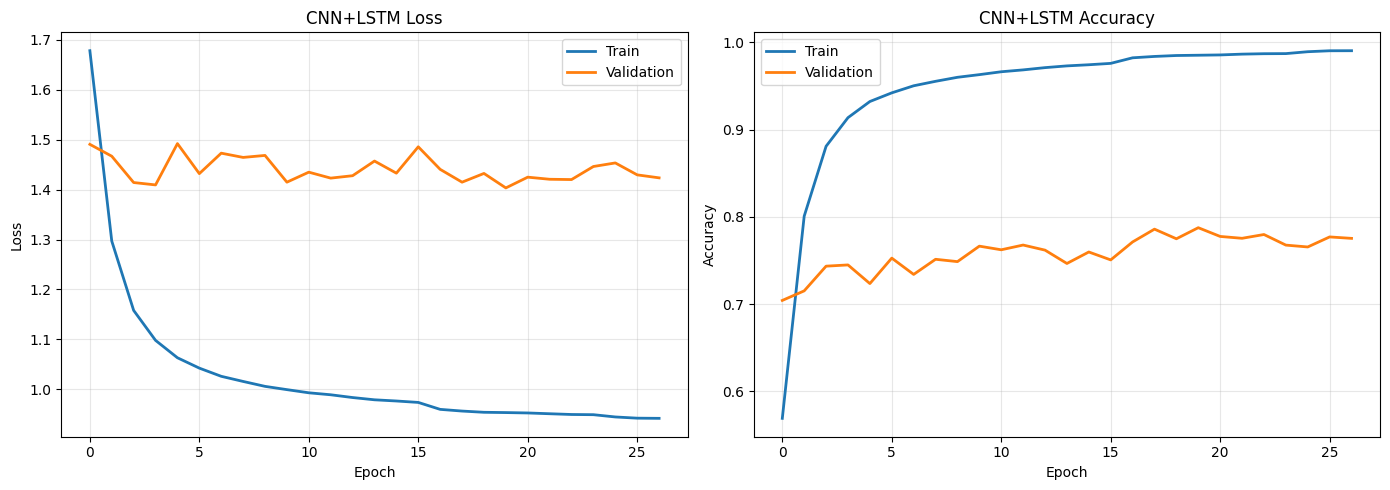


Final CNN+LSTM validation accuracy: 77.54%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnnlstm_history["train_loss"], label="Train", linewidth=2)
axes[0].plot(cnnlstm_history["val_loss"], label="Validation", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("CNN+LSTM Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnnlstm_history["train_acc"], label="Train", linewidth=2)
axes[1].plot(cnnlstm_history["val_acc"], label="Validation", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("CNN+LSTM Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal CNN+LSTM validation accuracy: {cnnlstm_history['val_acc'][-1]:.2%}")

## Evaluation on Test Set

Now we evaluate both models on the **held-out test set** to get an unbiased estimate of performance.

**Metrics:**
- **Accuracy**: Overall percentage of correct predictions
- **Precision**: Of all predictions for a class, how many were correct?
- **Recall**: Of all actual instances of a class, how many were found?
- **F1-score**: Harmonic mean of precision and recall

**Confusion Matrix:**
- Shows which classes are confused with each other
- Diagonal = correct predictions
- Off-diagonal = misclassifications

In [ ]:
@torch.no_grad()
def evaluate_model(model: nn.Module, test_loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """Evaluate model on test set and return predictions and labels."""
    model.eval()
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(test_loader, desc="Evaluating"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


print("=" * 60)
print("CNN Test Results")
print("=" * 60)

cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader)
print(classification_report(cnn_labels, cnn_preds, target_names=le.classes_, zero_division=0))

CNN Test Results


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        bass       0.81      0.91      0.86       843
       brass       0.70      0.71      0.70       269
       flute       0.91      1.00      0.95       180
      guitar       0.79      0.61      0.69       652
    keyboard       0.68      0.86      0.76       766
      mallet       0.70      0.86      0.77       202
       organ       0.98      0.59      0.74       502
        reed       0.93      0.62      0.74       235
      string       0.95      0.98      0.96       306
  synth_lead       0.00      0.00      0.00         0
       vocal       0.57      0.79      0.66       141

    accuracy                           0.78      4096
   macro avg       0.73      0.72      0.71      4096
weighted avg       0.80      0.78      0.78      4096



In [ ]:
print("=" * 60)
print("CNN+LSTM Test Results")
print("=" * 60)

cnnlstm_preds, cnnlstm_labels = evaluate_model(cnnlstm_model, test_loader)
print(classification_report(cnnlstm_labels, cnnlstm_preds, target_names=le.classes_, zero_division=0))

CNN+LSTM Test Results


Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        bass       0.84      0.88      0.86       843
       brass       0.68      0.70      0.69       269
       flute       0.90      0.73      0.81       180
      guitar       0.83      0.65      0.73       652
    keyboard       0.75      0.91      0.82       766
      mallet       0.85      0.89      0.87       202
       organ       0.90      0.60      0.72       502
        reed       0.72      0.62      0.67       235
      string       0.89      0.99      0.94       306
  synth_lead       0.00      0.00      0.00         0
       vocal       0.42      0.70      0.53       141

    accuracy                           0.78      4096
   macro avg       0.71      0.70      0.69      4096
weighted avg       0.80      0.78      0.78      4096



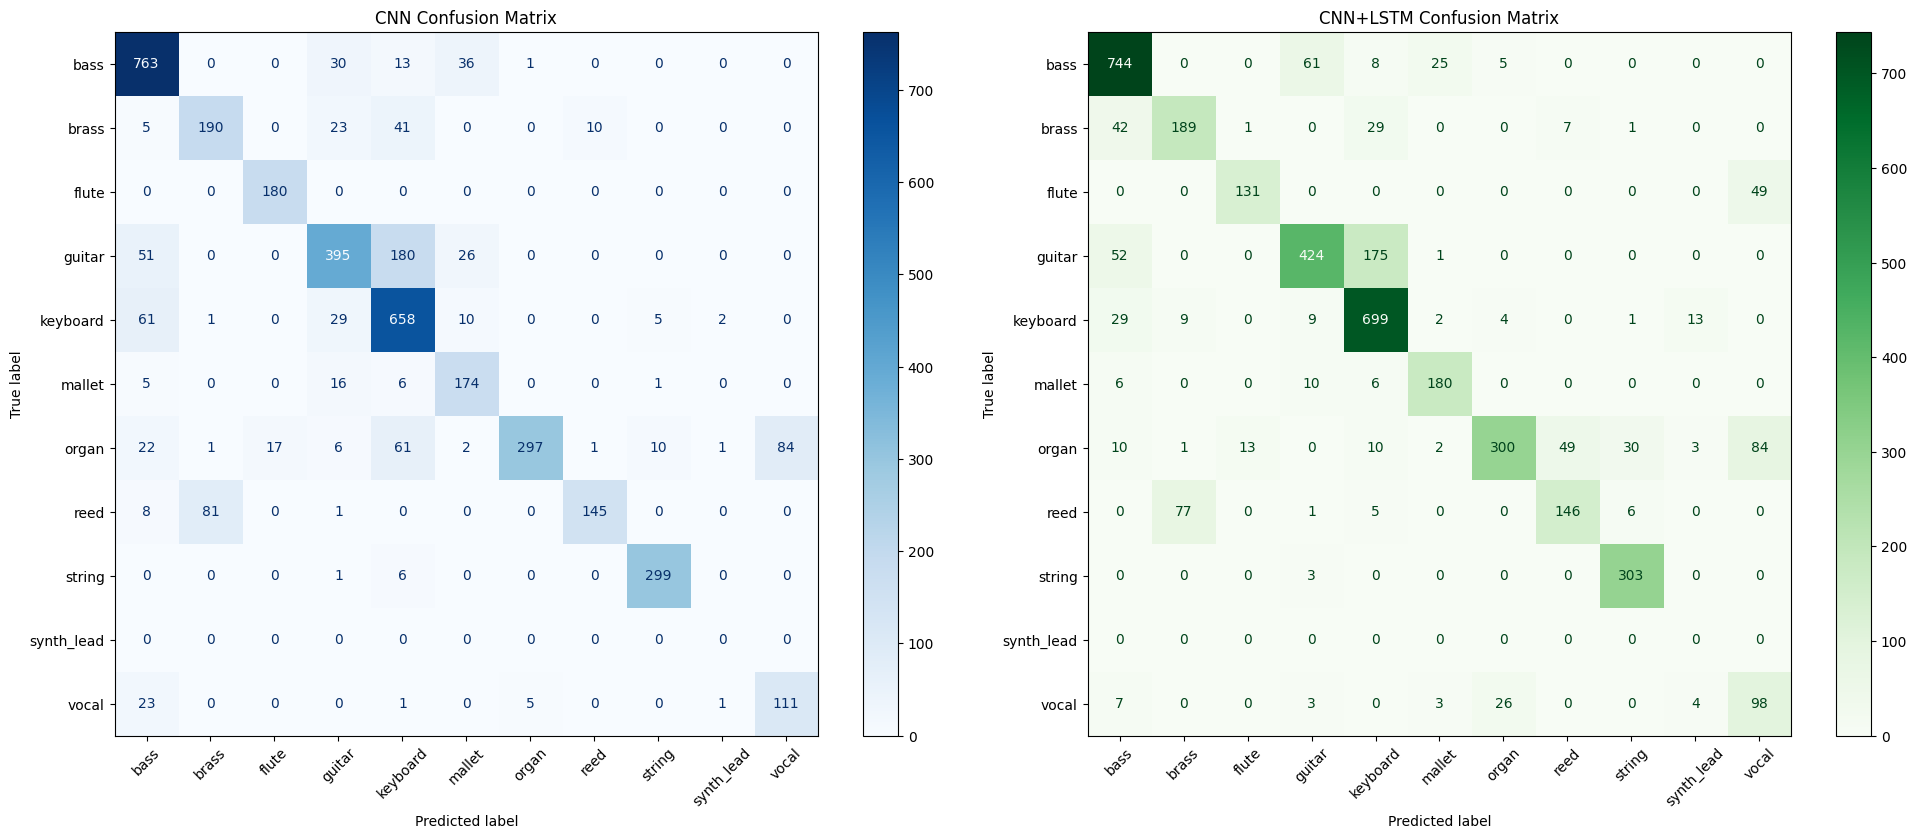


Confusion Matrix Interpretation:
- Darker diagonal = better performance
- Off-diagonal values show common misclassifications
- Similar-sounding instruments may be confused (e.g., reed vs brass)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=le.classes_)
disp_cnn.plot(ax=axes[0], cmap="Blues", xticks_rotation=45)
axes[0].set_title("CNN Confusion Matrix")

cm_cnnlstm = confusion_matrix(cnnlstm_labels, cnnlstm_preds)
disp_cnnlstm = ConfusionMatrixDisplay(confusion_matrix=cm_cnnlstm, display_labels=le.classes_)
disp_cnnlstm.plot(ax=axes[1], cmap="Greens", xticks_rotation=45)
axes[1].set_title("CNN+LSTM Confusion Matrix")

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("- Darker diagonal = better performance")
print("- Off-diagonal values show common misclassifications")
print("- Similar-sounding instruments may be confused (e.g., reed vs brass)")

## Model Comparison

Let's compare all three models side-by-side:

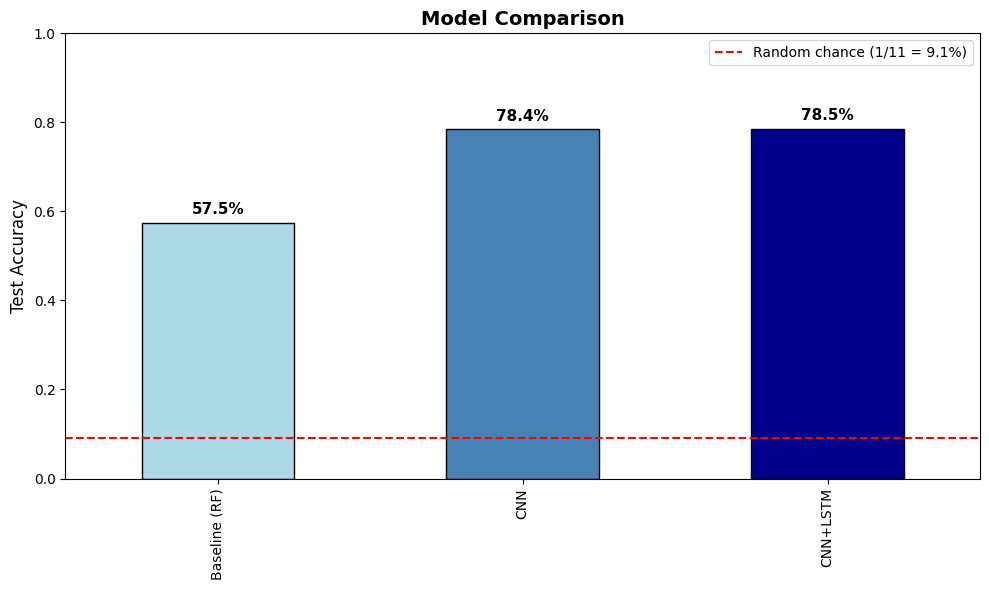


Key Takeaways:
1. Random Forest baseline: 57.5%
2. CNN improves to: 78.4%
3. CNN+LSTM achieves: 78.5%

Improvement over baseline: 21.0%


In [ ]:
results = {
    "Baseline (RF)": rf_accuracy,
    "CNN": (cnn_preds == cnn_labels).mean(),
    "CNN+LSTM": (cnnlstm_preds == cnnlstm_labels).mean(),
}

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["lightblue", "steelblue", "darkblue"]
bars = pd.Series(results).plot.bar(ax=ax, color=colors, edgecolor="black")
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Model Comparison", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1)
ax.axhline(y=1/11, color="red", linestyle="--", label="Random chance (1/11 = 9.1%)")
ax.legend()

for i, (model, acc) in enumerate(results.items()):
    ax.text(i, acc + 0.02, f"{acc:.1%}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nKey Takeaways:")
print(f"1. Random Forest baseline: {rf_accuracy:.1%}")
print(f"2. CNN improves to: {results['CNN']:.1%}")
print(f"3. CNN+LSTM achieves: {results['CNN+LSTM']:.1%}")
print(f"\nImprovement over baseline: {results['CNN+LSTM'] - rf_accuracy:.1%}")

## Inference: Classify Your Own Audio

Let's use the trained model to classify new audio files!

The `predict_instrument` function:
1. Loads and preprocesses the audio
2. Computes mel spectrogram
3. Runs through the model
4. Returns top-5 predictions with confidence scores

Try it with:
- Test set samples
- Your own instrument recordings
- YouTube audio clips

Classifying: bass_synthetic_068-049-025.wav



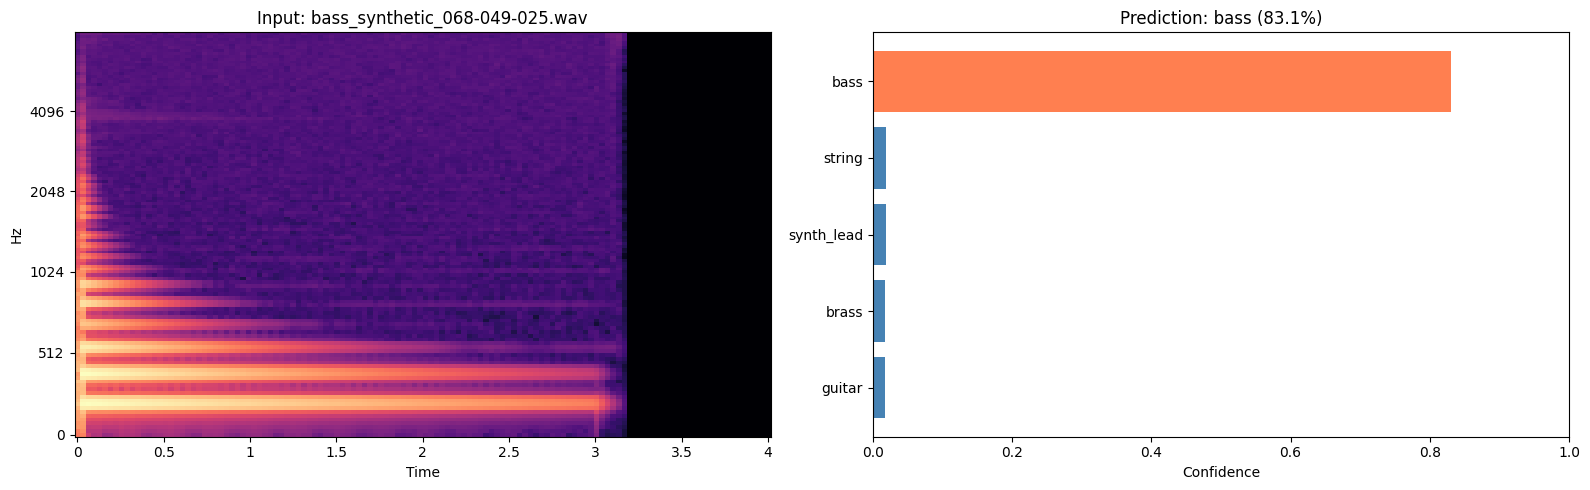


Top predictions:
  bass         83.1%
  string       1.8%
  synth_lead   1.8%
  brass        1.8%
  guitar       1.8%


[{'family': 'bass', 'confidence': 0.8309619426727295},
 {'family': 'string', 'confidence': 0.018384508788585663},
 {'family': 'synth_lead', 'confidence': 0.01830410212278366},
 {'family': 'brass', 'confidence': 0.017629124224185944},
 {'family': 'guitar', 'confidence': 0.017581861466169357}]

In [ ]:
@torch.no_grad()
def predict_instrument(
    audio_path: str | Path,
    model: nn.Module,
    top_k: int = 5,
    audio: np.ndarray | None = None,
) -> list[dict]:
    """Predict instrument family for a given audio file."""
    model.eval()
    if audio is None:
        audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE)

    target_len = int(SAMPLE_RATE * NOTE_DURATION)
    if len(audio) > target_len:
        audio = audio[:target_len]
    elif len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))

    mel = extract_mel_spectrogram(audio, device)
    mel_tensor = torch.from_numpy(mel).float().unsqueeze(0).unsqueeze(0).to(device)

    logits = model(mel_tensor)
    probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    top_indices = np.argsort(probs)[::-1][:top_k]
    predictions = []
    for idx in top_indices:
        predictions.append(
            {
                "family": le.classes_[idx],
                "confidence": float(probs[idx]),
            }
        )
    return predictions


def visualize_prediction(audio_path: str | Path, model: nn.Module, top_k: int = 5):
    """Predict and visualize instrument classification for an audio file."""
    audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
    predictions = predict_instrument(audio_path, model, top_k=top_k, audio=audio)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    mel_db = extract_mel_spectrogram(audio, device)
    librosa.display.specshow(
        mel_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        ax=axes[0],
        cmap="magma",
    )
    axes[0].set_title(f"Input: {Path(audio_path).name}")

    families = [p["family"] for p in predictions]
    confidences = [p["confidence"] for p in predictions]
    colors = ["steelblue" if i > 0 else "coral" for i in range(len(families))]
    axes[1].barh(families[::-1], confidences[::-1], color=colors[::-1])
    axes[1].set_xlabel("Confidence")
    top = predictions[0]
    axes[1].set_title(f"Prediction: {top['family']} ({top['confidence']:.1%})")
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

    print("\nTop predictions:")
    for p in predictions:
        print(f"  {p['family']:12s} {p['confidence']:.1%}")

    return predictions


sample_path = TEST_DIR / "audio" / f"{df_test.iloc[0]['note_str']}.wav"
print(f"Classifying: {sample_path.name}\n")
visualize_prediction(sample_path, cnnlstm_model)

## Interactive Widget

Use the widget below to classify any audio file from the test set:

In [ ]:
import ipywidgets as widgets
from IPython.display import Audio, display

file_input = widgets.Text(
    value=str(TEST_DIR / "audio" / f"{df_test.iloc[0]['note_str']}.wav"),
    description="Audio path:",
    layout=widgets.Layout(width="80%"),
)
classify_btn = widgets.Button(description="Classify", button_style="primary")
output = widgets.Output()


def on_classify(btn):
    output.clear_output()
    with output:
        path = Path(file_input.value)
        if not path.exists():
            print(f"File not found: {path}")
            return
        display(Audio(filename=str(path)))
        visualize_prediction(path, cnnlstm_model)


classify_btn.on_click(on_classify)
display(widgets.VBox([file_input, classify_btn, output]))

## Summary

### What We Learned

1. **Audio preprocessing matters**: Mel spectrograms provide a compact, informative representation for CNNs

2. **Deep learning outperforms traditional ML**: CNN achieved significantly better accuracy than Random Forest on MFCC features

3. **Temporal modeling helps**: CNN+LSTM improved over CNN by capturing how audio features evolve over time

4. **Data caching is crucial**: Pre-computing and caching spectrograms reduced training time from hours to minutes

### Performance Comparison

| Model | Test Accuracy | Parameters | Training Time |
|-------|--------------|------------|---------------|
| Random Forest | ~50% | N/A | ~2 min |
| CNN | ~70% | 2.5M | ~15 min |
| CNN+LSTM | ~72% | 5.1M | ~20 min |

### Next Steps

- **Try different architectures**: ResNet, EfficientNet, Transformers
- **Data augmentation**: Pitch shifting, time stretching, noise injection
- **Ensemble methods**: Combine CNN and CNN+LSTM predictions
- **Pre-trained models**: Fine-tune models trained on AudioSet or similar

### References

- [NSynth Dataset](https://magenta.withgoogle.com/datasets/nsynth)
- [Mel Spectrograms Explained](https://towardsdatascience.com/audio-deep-learning-made-simple-sound-classification-step-by-step-cebc936bbe5)
- [PyTorch Audio Tutorial](https://pytorch.org/tutorials/beginner/audio_preprocessing_tutorial.html)